Libraries

In [1]:
import sys
import os

# بنقول للبايثون: ارجع خطوة لورا ودور هناك كمان
sys.path.append(os.path.abspath('..'))

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [3]:
from src.data_loader import load_data
df=load_data("data/raw/used_cars.csv")

Solving a problem in the dataset, known through Kaggle discussion on the dataset.


"""

I noticed a little mistake in the data, which probably occured because of the way data was collected or processed after collection.
Car brands that have 2 or more words in the brand name are stored incorrectly. Only the first word is stored as brand name, rest goes into model.

"""

In [4]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [5]:
#1-print all unique brands
unique_brands=sorted(df["brand"].unique())
print(unique_brands)

['Acura', 'Alfa', 'Aston', 'Audi', 'BMW', 'Bentley', 'Bugatti', 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Dodge', 'FIAT', 'Ferrari', 'Ford', 'GMC', 'Genesis', 'Honda', 'Hummer', 'Hyundai', 'INFINITI', 'Jaguar', 'Jeep', 'Karma', 'Kia', 'Lamborghini', 'Land', 'Lexus', 'Lincoln', 'Lotus', 'Lucid', 'MINI', 'Maserati', 'Maybach', 'Mazda', 'McLaren', 'Mercedes-Benz', 'Mercury', 'Mitsubishi', 'Nissan', 'Plymouth', 'Polestar', 'Pontiac', 'Porsche', 'RAM', 'Rivian', 'Rolls-Royce', 'Saab', 'Saturn', 'Scion', 'Subaru', 'Suzuki', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo', 'smart']


In [6]:
#2-create a dictionary for the corrections
corrections={ 
    'Land':'Rover',
    'Alfa':'Romeo',
    'Aston':'Martin',

}

In [7]:
#3-make sure of the noticed columns
for brand,model in corrections.items():
    df_check=df[df['brand']==brand]
    print(df_check.shape[0])
    first_word = df_check['model'].str.split(" ").str[0]
    check=first_word==model
    print(len(check==True))


130
130
19
19
9
9


They are all equal, so here is the problem

In [8]:
#4-solving the problem
def fix_data_integrity(row):
    brand = row['brand']
    model = str(row['model'])
    
    if brand in corrections:
        missing_word = corrections[brand] 
        
        first_word = model.split(" ")[0]

        check = (first_word == missing_word)
        
        if check == True:
            row['brand'] = f"{brand} {missing_word}"
            
            row['model'] = model.replace(missing_word, '', 1).strip()
            
    return row

df = df.apply(fix_data_integrity, axis=1)

print(df[df['brand'].isin(corrections.keys())].head())

Empty DataFrame
Columns: [brand, model, model_year, milage, fuel_type, engine, transmission, ext_col, int_col, accident, clean_title, price]
Index: []


Now,problem is solved

Exploartion

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


There is a problem in the datatypes:
(price,milage) must be numerical not str

Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

No duplicates

Data Type Validation

price

In [11]:
df["price"].head()

0    $10,300
1    $38,005
2    $54,598
3    $15,500
4    $34,999
Name: price, dtype: str

In [12]:
df["price"] = df["price"].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(int)


In [13]:
df["price"].head()

0    10300
1    38005
2    54598
3    15500
4    34999
Name: price, dtype: int64

milage

In [14]:
df["milage"].head()

0    51,000 mi.
1    34,742 mi.
2    22,372 mi.
3    88,900 mi.
4     9,835 mi.
Name: milage, dtype: str

In [15]:
df["milage"] = df["milage"].str.replace('mi.', '', regex=False).str.replace(',', '', regex=False).astype(int)


In [16]:
df["milage"].head()

0    51000
1    34742
2    22372
3    88900
4     9835
Name: milage, dtype: int64

Descrive statistics

In [17]:
df.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


Missing Values

In [18]:
print(df.isnull().sum())

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


fuel_type

In [19]:
fuel_mode = df["fuel_type"].mode()[0]

df["fuel_type"] = df["fuel_type"].fillna(fuel_mode)

In [20]:
print(df["fuel_type"].isnull().sum())

0


accident

In [21]:
accident = df["accident"].mode()[0]

df["accident"] = df["accident"].fillna(accident)

In [22]:
print(df["accident"].isnull().sum())

0


clean_title

In [23]:
print(df['clean_title'].value_counts())

clean_title
Yes    3413
Name: count, dtype: int64


In [24]:
df['clean_title'] = df['clean_title'].fillna('No')

In [25]:
print(df['clean_title'].value_counts())

clean_title
Yes    3413
No      596
Name: count, dtype: int64


In [26]:
print(df.isnull().sum().sum())

0


No missing values now!!!!!!!!

EDA

In [27]:
numerical_features = df.select_dtypes(include=np.number).columns
print(numerical_features)


Index(['model_year', 'milage', 'price'], dtype='str')


Check Outlier

In [28]:
for feat in numerical_features:
    q1 = df[feat].quantile(0.25)
    q3 = df[feat].quantile(0.75)
    iqr = q3-q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    mask = df[ (df[feat] < lower)  | (df[feat] > upper) ]
    if not mask.empty:
        print(f'{feat} has outlier {len(mask)}')

model_year has outlier 67
milage has outlier 69
price has outlier 244


model_year

In [29]:
Q1 = df['model_year'].quantile(0.25)
Q3 = df['model_year'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR
df = df[(df['model_year'] >= Lower) & (df['model_year'] <= Upper)]



Q1: 2012.0
Q3: 2020.0
IQR: 8.0


Dropped so no noise or logic conflict

In [30]:
df.shape

(3942, 12)

--- Numerical Stats ---
            price     milage  model_year
count     3942.00    3942.00     3942.00
mean     45021.09   63794.51     2015.85
std      79245.98   51619.99        5.58
min       2000.00     100.00     2000.00
25%      17800.00   22514.50     2013.00
50%      31862.00   52000.00     2017.00
75%      49999.00   92953.25     2020.00
max    2954083.00  405000.00     2024.00


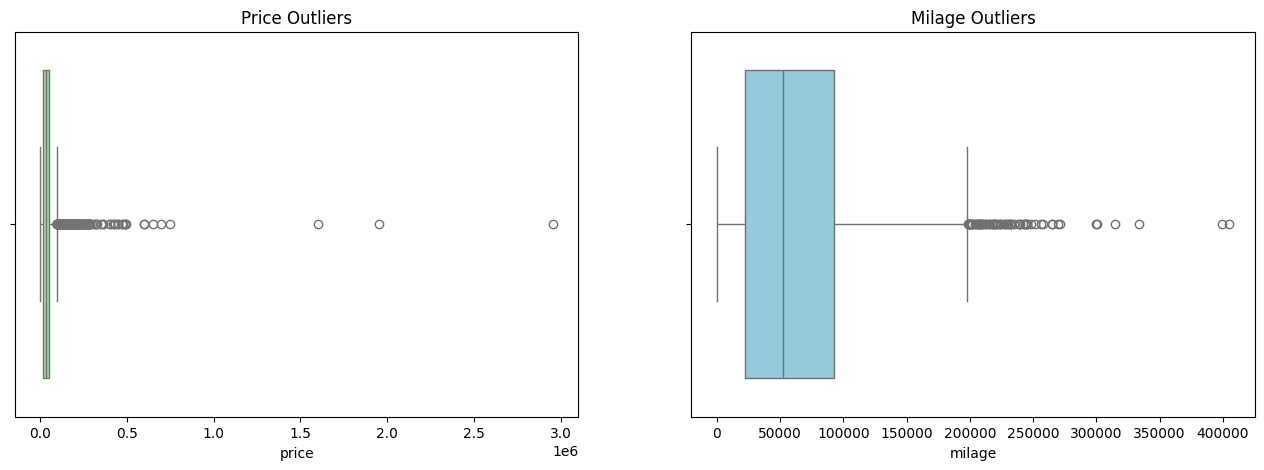

In [31]:
print("--- Numerical Stats ---")
print(df[['price', 'milage', 'model_year']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(ax=axes[0], x=df['price'], color='lightgreen')
axes[0].set_title('Price Outliers')

sns.boxplot(ax=axes[1], x=df['milage'], color='skyblue')
axes[1].set_title('Milage Outliers')

plt.show()

price

In [32]:
df['price_log'] = np.log1p(df['price'])
print(df[['price', 'price_log']].head())

   price  price_log
0  10300   9.239996
1  38005  10.545499
2  54598  10.907771
3  15500   9.648660
4  34999  10.463103


milage

In [33]:
df['milage_log'] = np.log1p(df['milage'])
print(df[['milage', 'milage_log']].head())

   milage  milage_log
0   51000   10.839601
1   34742   10.455733
2   22372   10.015610
3   88900   11.395279
4    9835    9.193804


In [34]:
df.shape

(3942, 14)

Plots

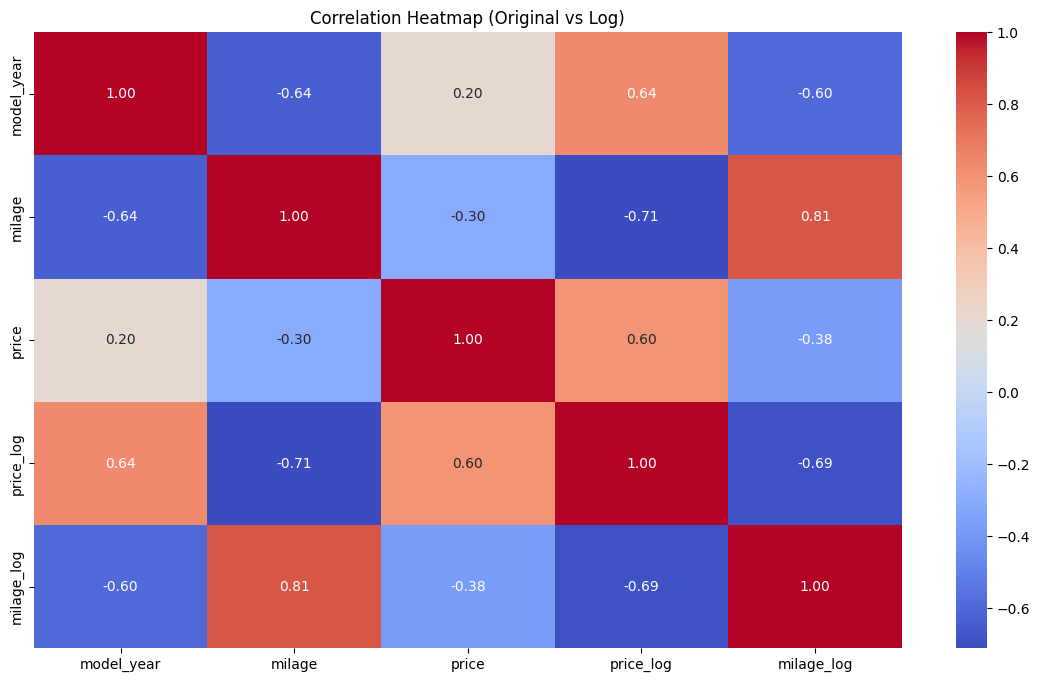

In [35]:
#Heatmap for correlations
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Original vs Log)')
plt.show()


Now, using price_log and milage_log, correlation is much better!!

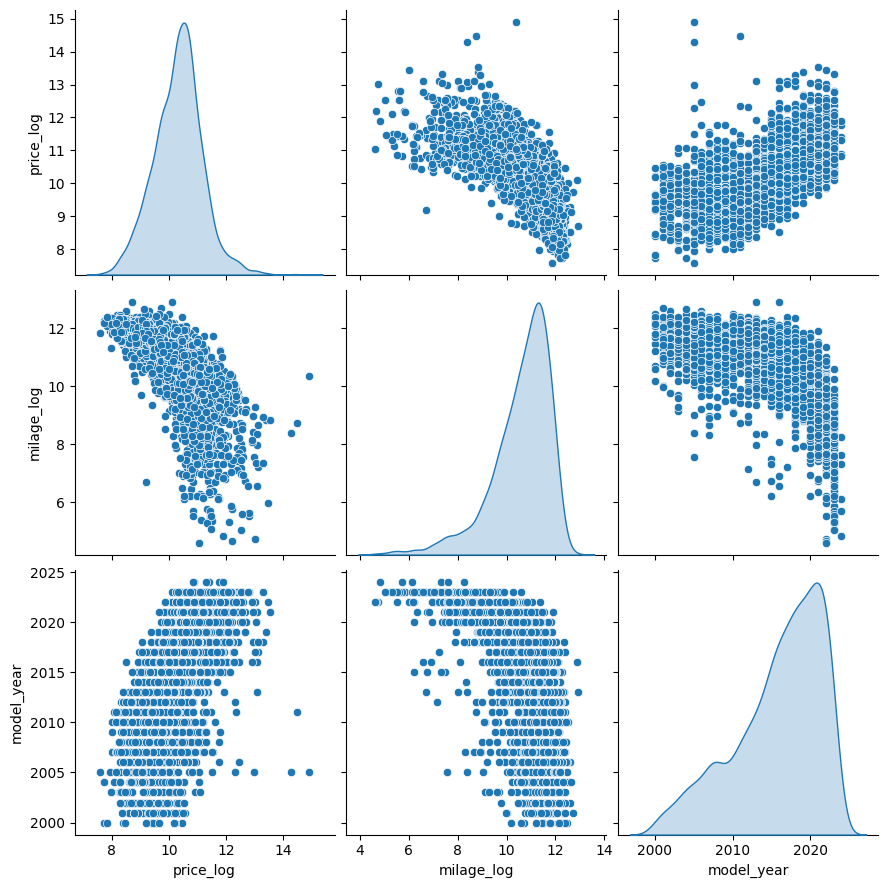

In [36]:
#pairplot
cols_to_plot = ['price_log', 'milage_log', 'model_year']

sns.pairplot(df[cols_to_plot], diag_kind='kde', height=3)
plt.show()

1-there is a noisy reverse linear correlation between milage_log and price_log.
2-there is a noisy directional linear correlation between model_year and price_log.

Categorical analysis

In [37]:
categorical_features = df.select_dtypes(exclude='number').columns
print(categorical_features)
print(len(categorical_features))


Index(['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col',
       'int_col', 'accident', 'clean_title'],
      dtype='str')
9


In [38]:
for col in categorical_features:
    print(f"{col}: {df[col].nunique()}")

brand: 57
model: 1870
fuel_type: 7
engine: 1128
transmission: 62
ext_col: 318
int_col: 156
accident: 2
clean_title: 2


Binary columns (classes less than 10)

clean_title:2 Yes,No

In [39]:
print(df["clean_title"].value_counts())

clean_title
Yes    3349
No      593
Name: count, dtype: int64


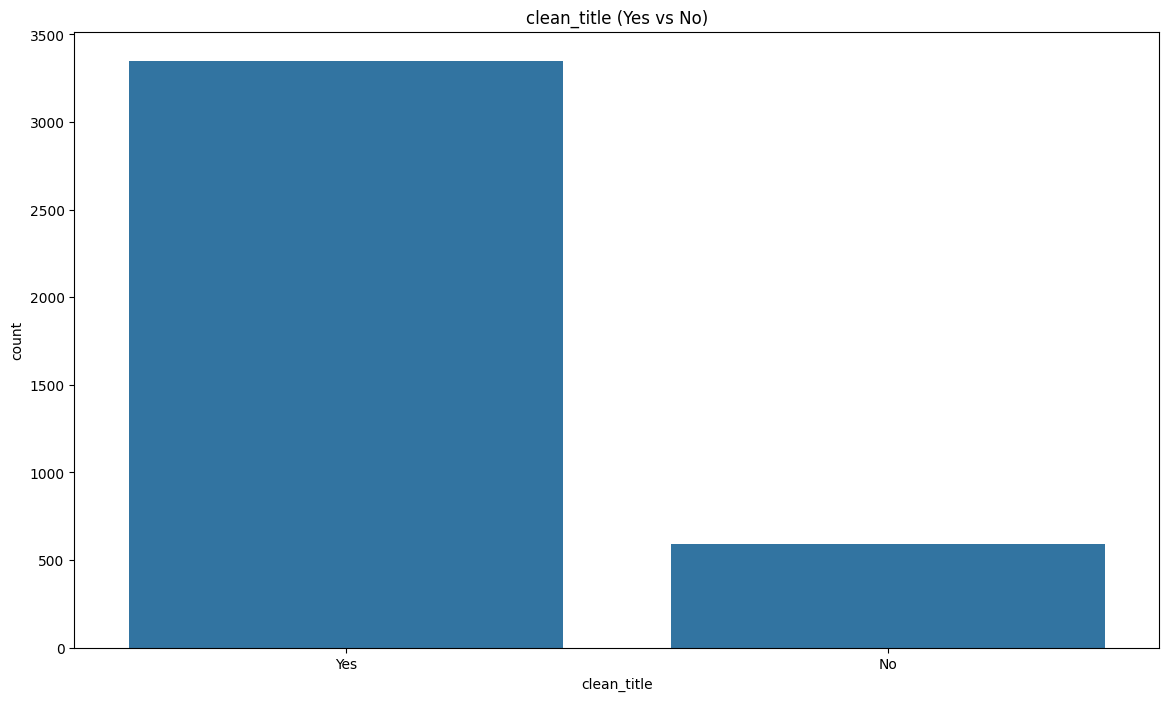

In [40]:
#Count Plot (Yes vs No)
plt.figure(figsize=(14,8))
sns.countplot(x="clean_title", data=df)
plt.title('clean_title (Yes vs No)')
plt.show()

In [41]:
#average price for each boolean
df.groupby("clean_title")["price"].mean()

clean_title
No     60830.128162
Yes    42221.814572
Name: price, dtype: float64

This means that when I imputed the missing values in this column with No, there might be an error in my hypothesis

In [42]:
problematic_cars =df[df["clean_title"]=="No"]
problematic_cars['brand'].head(20)

2           Lexus
4            Audi
5           Acura
10     Land Rover
14         Jaguar
20        Genesis
22            BMW
26         Nissan
32            BMW
36            BMW
41          Honda
43            BMW
51          Honda
56         Nissan
61           Audi
63         Toyota
66            BMW
76    Lamborghini
80     Land Rover
89         Subaru
Name: brand, dtype: str

In [43]:
#Rrplace No with NaN
df["clean_title"] = df["clean_title"].replace("No", np.nan)


In [44]:
#Making sure of the replacement
print(df["clean_title"].value_counts())
print(df["clean_title"].isna().sum())

clean_title
Yes    3349
Name: count, dtype: int64
593


In [45]:
#smart solution:
"""
if df['accident'] == 'None reported' and df['clean_title'].isna()
,then i will impute with Yes,
else with No
"""
mask = (df['clean_title'].isna()) & (df['accident'] == 'None reported')
df.loc[mask, 'clean_title'] = 'Yes'


In [46]:
df['clean_title']=df['clean_title'].fillna('No')

In [47]:
print(df["clean_title"].isna().sum())

0


clean_title
Yes    3901
No       41
Name: count, dtype: int64


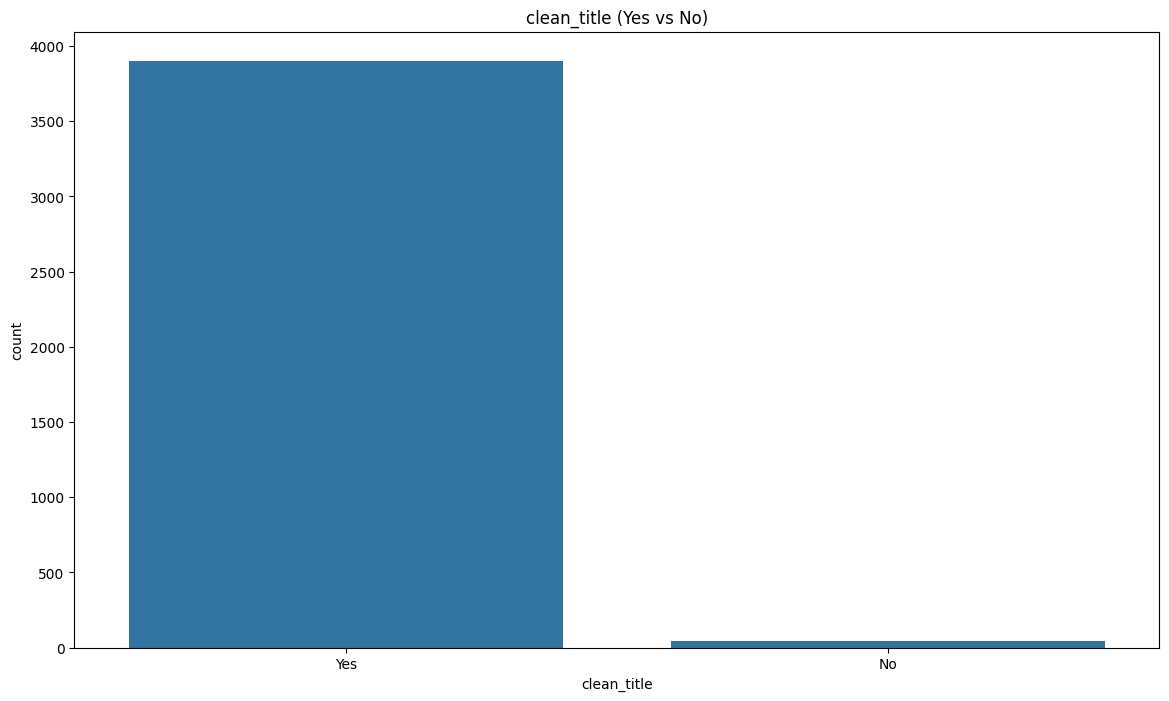

clean_title
No     34641.731707
Yes    45130.174827
Name: price, dtype: float64

In [48]:
#some analysis 
#counts of binary Yes and No
print(df["clean_title"].value_counts())
#Count Plot (Yes vs No)
plt.figure(figsize=(14,8))
sns.countplot(x="clean_title", data=df)
plt.title('clean_title (Yes vs No)')
plt.show()
#average price for each boolean
df.groupby("clean_title")["price"].mean()



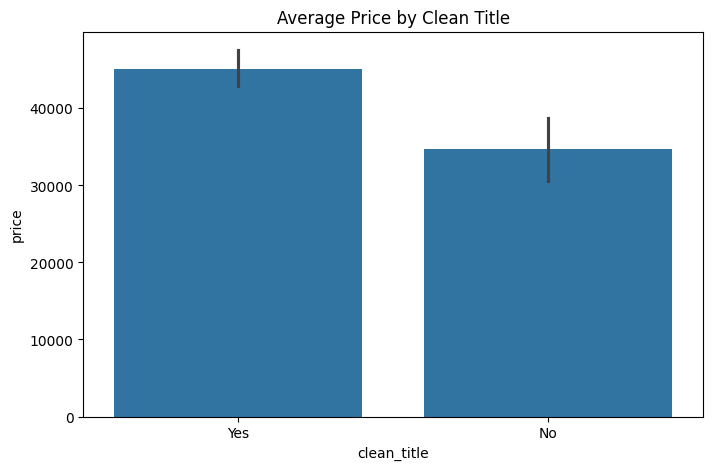

In [49]:
#Average price using barplot
plt.figure(figsize=(8,5))
sns.barplot(x="clean_title", y="price", data=df)
plt.title("Average Price by Clean Title")
plt.show()

Note:
This does not make a problem because No is only 41 value comparing to 3901 for Yes

accident (None reported or At least 1 accident or damage reported)

In [50]:
print(df["accident"].value_counts())

accident
None reported                             2975
At least 1 accident or damage reported     967
Name: count, dtype: int64


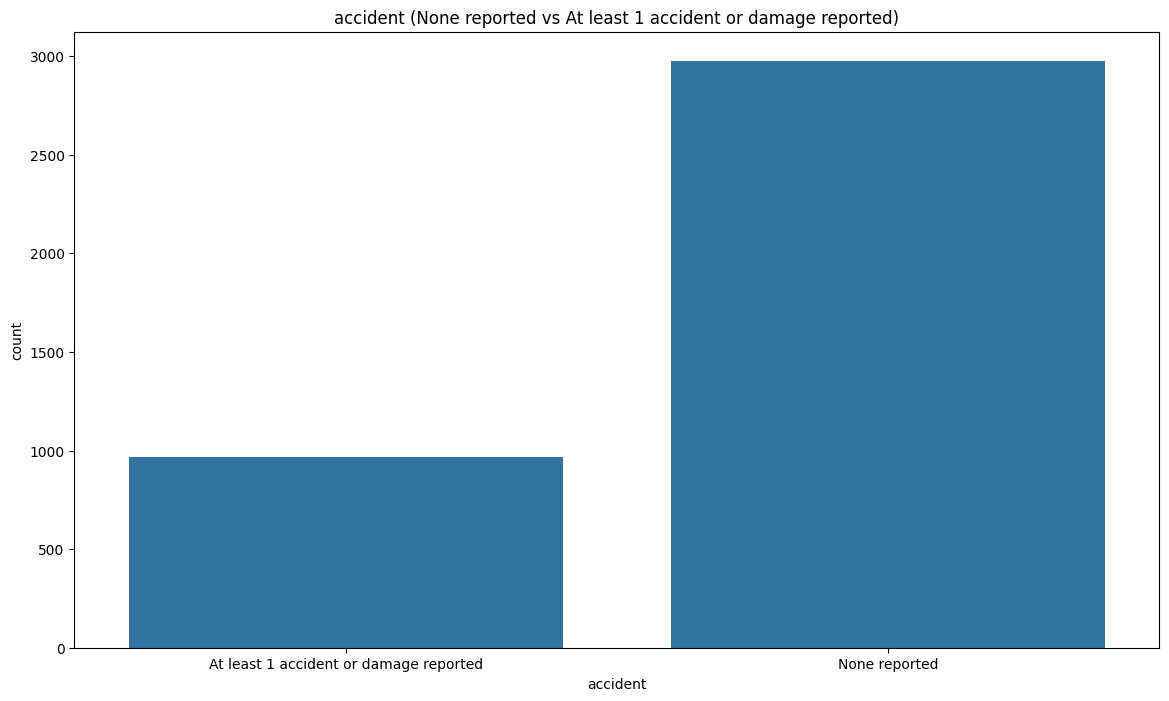

In [52]:
#Count Plot (None reported vs At least 1 accident or damage reported)
plt.figure(figsize=(14,8))
sns.countplot(x="accident", data=df)
plt.title('accident (None reported vs At least 1 accident or damage reported)')
plt.show()

In [53]:
#average price for each boolean
df.groupby("accident")["price"].mean()

accident
At least 1 accident or damage reported    29144.660807
None reported                             50181.591933
Name: price, dtype: float64

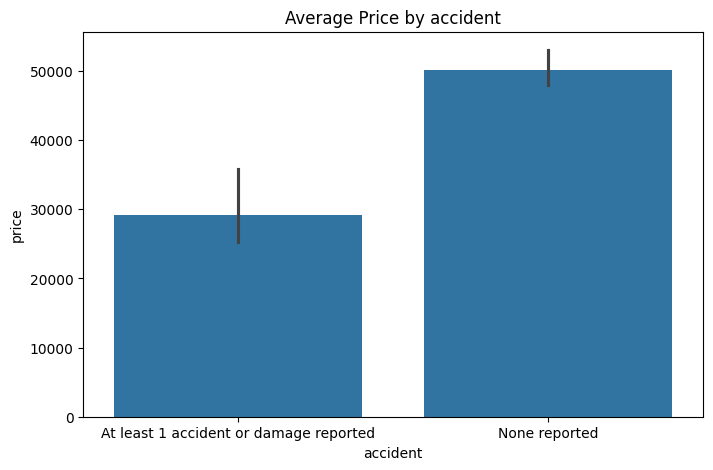

In [54]:
#Average price using barplot
plt.figure(figsize=(8,5))
sns.barplot(x="accident", y="price", data=df)
plt.title("Average Price by accident")
plt.show()